In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from jiwer import cer, wer
from collections import Counter
import os

%matplotlib inline

In [16]:
df_tess = pd.read_csv('tesseract_baseline.csv', encoding='utf-8')
df_trocr = pd.read_csv('trocr_baseline.csv', encoding='utf-8')

In [17]:
def calculate_metrics(df, model_name):
    def _calc(row):
        ref = str(row['reference']) if pd.notna(row['reference']) else ''
        hyp = str(row['hypothesis']) if pd.notna(row['hypothesis']) else ''
        return pd.Series({
            'cer': cer(ref, hyp),
            'wer': wer(ref, hyp),
            'ref_len': len(ref),
            'hyp_len': len(hyp)
        })
    
    metrics = df.apply(_calc, axis=1)
    df = pd.concat([df, metrics], axis=1)

    print(f"Средний CER: {df['cer'].mean():.4f}")
    print(f"Средний WER: {df['wer'].mean():.4f}")
    print(f"Идеальные строки (CER=0): {(df['cer'] == 0).mean():.2%}")
    print(f"Медианный CER: {df['cer'].median():.4f}")
    print()
    return df

df_tess = calculate_metrics(df_tess, "Tesseract (baseline)")
df_trocr = calculate_metrics(df_trocr, "TrOCR")

Средний CER: 0.5163
Средний WER: 0.9320
Идеальные строки (CER=0): 0.07%
Медианный CER: 0.5000

Средний CER: 0.0333
Средний WER: 0.0862
Идеальные строки (CER=0): 56.89%
Медианный CER: 0.0000



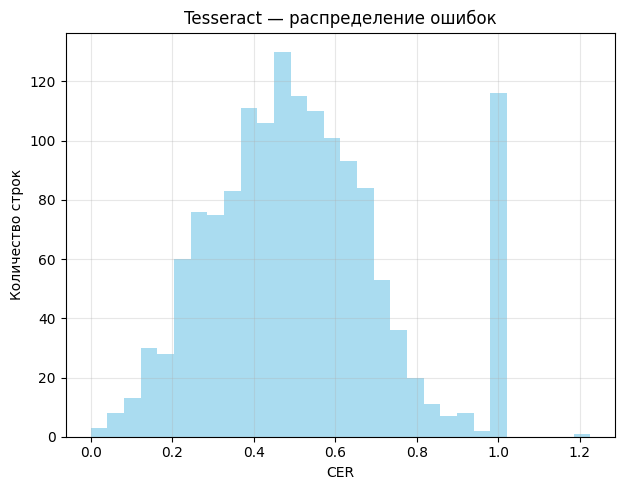

In [34]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df_tess['cer'], bins=30, alpha=0.7, color='skyblue')
plt.xlabel('CER')
plt.ylabel('Количество строк')
plt.title('Tesseract — распределение ошибок')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

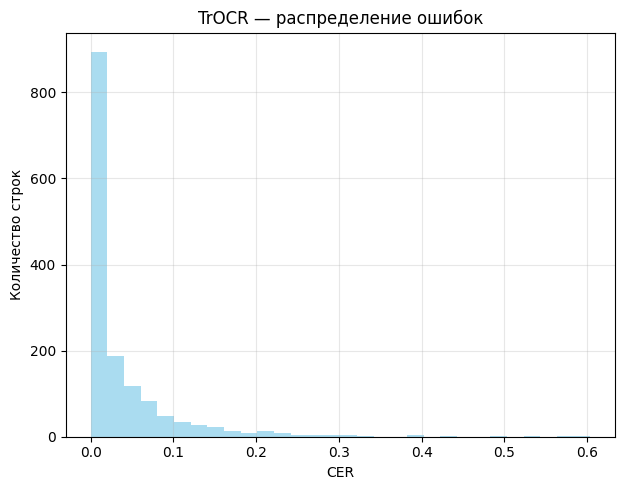

In [18]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df_trocr['cer'], bins=30, alpha=0.7, color='skyblue')
plt.xlabel('CER')
plt.ylabel('Количество строк')
plt.title('TrOCR — распределение ошибок')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
def get_top_substitutions(df, top_n=10):
    subs = []
    for _, row in df.iterrows():
        ref = str(row['reference'])
        hyp = str(row['hypothesis'])
        min_len = min(len(ref), len(hyp))
        for i in range(min_len):
            if ref[i] != hyp[i]:
                subs.append(f"'{ref[i]}' → '{hyp[i]}'")
    return Counter(subs).most_common(top_n)

print("🔍 Топ-10 самых частых замен символов(Tesseract):")
for sub, count in get_top_substitutions(df_tess):
    print(f"  {sub}: {count} раз(а)")

print("🔍 Топ-10 самых частых замен символов(TrOCR:")
for sub, count in get_top_substitutions(df_trocr):
    print(f"  {sub}: {count} раз(а)")

🔍 Топ-10 самых частых замен символов(Tesseract):
  'e' → ' ': 930 раз(а)
  ' ' → 'e': 848 раз(а)
  't' → ' ': 686 раз(а)
  ' ' → 'a': 632 раз(а)
  'a' → ' ': 589 раз(а)
  'o' → ' ': 560 раз(а)
  ' ' → 'o': 524 раз(а)
  'n' → ' ': 501 раз(а)
  'i' → ' ': 462 раз(а)
  's' → ' ': 450 раз(а)
🔍 Топ-10 самых частых замен символов(TrOCR:
  ' ' → 'e': 196 раз(а)
  'e' → ' ': 186 раз(а)
  't' → ' ': 182 раз(а)
  ' ' → 't': 166 раз(а)
  'r' → 'e': 135 раз(а)
  ' ' → 's': 132 раз(а)
  ' ' → 'a': 132 раз(а)
  'o' → ' ': 127 раз(а)
  ' ' → 'o': 126 раз(а)
  'a' → ' ': 123 раз(а)


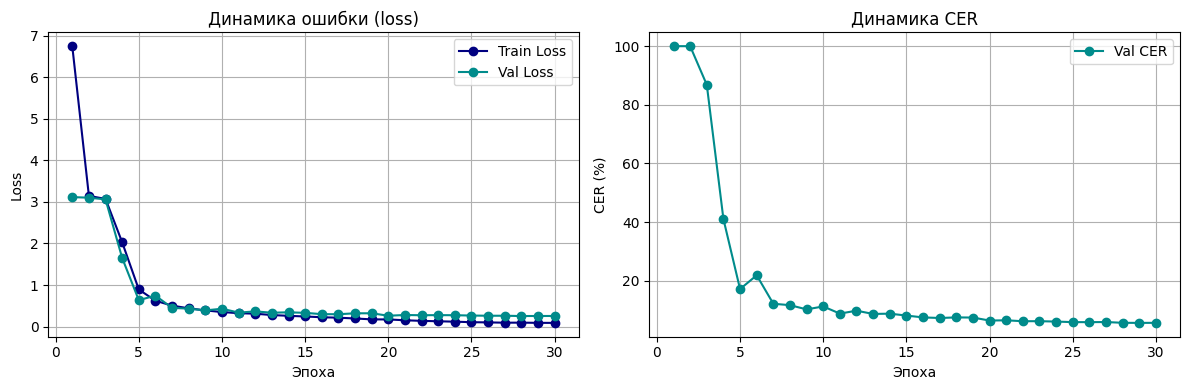

In [36]:
epochs = list(range(1, 31))

train_loss = [6.7494, 3.1455, 3.0727, 2.0287, 0.8930, 0.6216, 0.5039, 0.4398, 0.3895, 0.3496,
              0.3222, 0.3100, 0.2776, 0.2589, 0.2428, 0.2242, 0.2138, 0.1948, 0.1733, 0.1717,
              0.1517, 0.1375, 0.1276, 0.1179, 0.1054, 0.1005, 0.0934, 0.0944, 0.0897, 0.0887]

val_loss = [3.1164, 3.1020, 3.0618, 1.6515, 0.6357, 0.7449, 0.4497, 0.4320, 0.3886, 0.4298,
            0.3362, 0.3651, 0.3334, 0.3432, 0.3305, 0.2987, 0.2971, 0.3195, 0.3199, 0.2612,
            0.2784, 0.2728, 0.2755, 0.2731, 0.2655, 0.2606, 0.2609, 0.2534, 0.2550, 0.2549]

val_cer = [100.00, 100.00, 86.82, 41.02, 17.12, 21.82, 12.11, 11.63, 10.19, 11.19,
           8.75, 9.74, 8.63, 8.73, 8.08, 7.45, 7.25, 7.45, 7.40, 6.38,
           6.46, 6.15, 6.16, 6.03, 5.84, 5.83, 5.87, 5.61, 5.58, 5.60]

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, 'o-', color='navy', label='Train Loss')
plt.plot(epochs, val_loss, 'o-', color='darkcyan', label='Val Loss')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Динамика ошибки (loss)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, val_cer, 'o-', color='darkcyan', label='Val CER')
plt.xlabel('Эпоха')
plt.ylabel('CER (%)')
plt.title('Динамика CER')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [37]:
df = pd.read_excel('recognition_errors.xlsx')

In [38]:
df['cer_value'] = df['CER'].str.replace('%', '').astype(float)
print("СТАТИСТИКА ОШИБОК (худшие распознавания)")
print(f"Количество примеров: {len(df)}")
print(f"Минимальный CER: {df['cer_value'].min():.1f}%")
print(f"Максимальный CER: {df['cer_value'].max():.1f}%")
print(f"Средний CER: {df['cer_value'].mean():.1f}%")
print(f"Медианный CER: {df['cer_value'].median():.1f}%")


СТАТИСТИКА ОШИБОК (худшие распознавания)
Количество примеров: 1229
Минимальный CER: 1.5%
Максимальный CER: 55.9%
Средний CER: 8.1%
Медианный CER: 6.2%


In [39]:
print("Худшие распознавания:")
for _, row in df_tess.nlargest(3, 'cer').iterrows():
    print(f"  О: {row['reference']}")
    print(f"  П: {row['hypothesis']}")
    print(f"  CER: {row['cer']:.2f}\n")

Худшие распознавания:
  О: view and remembering the advice
  П: JUELO 92907 AE 1271 C007 CLLCA flele SIEVE
  CER: 1.23

  О: are , beyond personal security ,
  П: nan
  CER: 1.00

  О: faces very disconcerting ; and looking at
  П: nan
  CER: 1.00



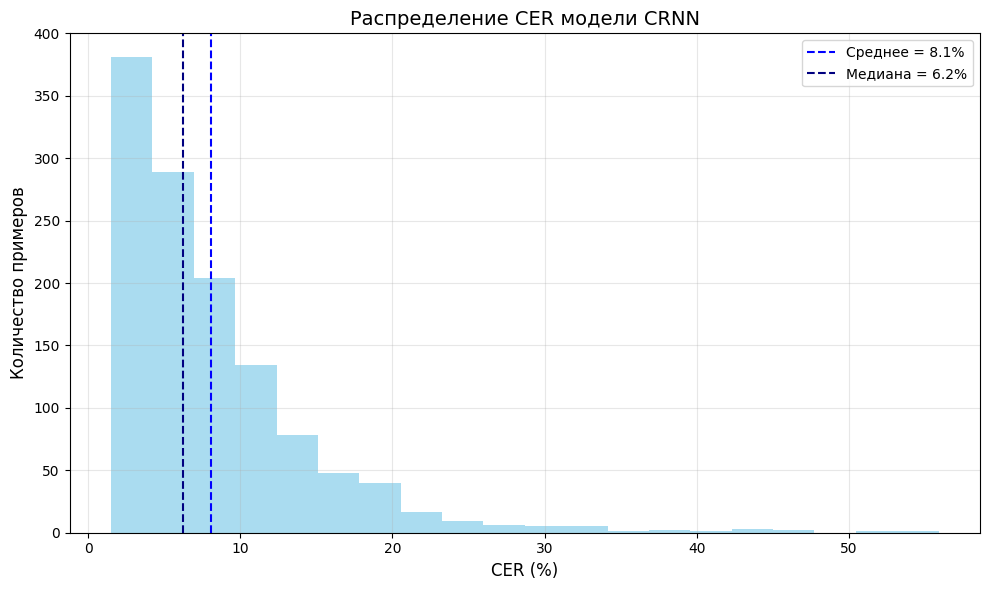

In [40]:
plt.figure(figsize=(10, 6))
plt.hist(df['cer_value'], bins=20, alpha=0.7, color='skyblue')
plt.xlabel('CER (%)', fontsize=12)
plt.ylabel('Количество примеров', fontsize=12)
plt.title('Распределение CER модели CRNN', fontsize=14)
plt.axvline(df['cer_value'].mean(), color='blue', linestyle='--', label=f'Среднее = {df["cer_value"].mean():.1f}%')
plt.axvline(df['cer_value'].median(), color='navy', linestyle='--', label=f'Медиана = {df["cer_value"].median():.1f}%')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [41]:
def extract_error_patterns(ref, hyp):
    ref = str(ref)
    hyp = str(hyp)
    min_len = min(len(ref), len(hyp))
    
    substitutions = []
    for i in range(min_len):
        if ref[i] != hyp[i]:
            substitutions.append(f"'{ref[i]}' → '{hyp[i]}'")
    if len(hyp) > len(ref):
        extra = hyp[len(ref):]
        if extra:
            substitutions.append(f"+'{extra}'")
    if len(ref) > len(hyp):
        missing = ref[len(hyp):]
        if missing:
            substitutions.append(f"-'{missing}'")
    
    return substitutions

all_errors = []
all_patterns = []

for _, row in df.iterrows():
    errors = extract_error_patterns(row['Оригинальный текст'], row['Распознано моделью'])
    all_errors.extend(errors)
    ref_words = str(row['Оригинальный текст']).split()
    hyp_words = str(row['Распознано моделью']).split()
    for rw, hw in zip(ref_words, hyp_words):
        if rw != hw:
            all_patterns.append((rw, hw))

error_counter = Counter(all_errors)
print("🔍 Топ-10 самых частых замен символов:")
for err, count in error_counter.most_common(10):
    print(f"  {err}: {count} раз")


🔍 Топ-10 самых частых замен символов:
  'e' → ' ': 383 раз
  't' → ' ': 312 раз
  ' ' → 't': 303 раз
  ' ' → 'a': 268 раз
  ' ' → 'e': 257 раз
  's' → ' ': 235 раз
  'd' → ' ': 215 раз
  ' ' → 's': 213 раз
  ' ' → 'h': 208 раз
  ' ' → 'o': 201 раз


In [27]:
df = pd.read_excel('recognition_errors.xlsx')
df['cer_value'] = df['CER'].str.replace('%', '').astype(float) / 100
df_sorted = df.sort_values('cer_value', ascending=False)
print("ХУДШИЕ РАСПОЗНАВАНИЯ (CRNN):")
print("="*60)

for i, row in df_sorted.head(5).iterrows():
    print(f"\n  О: {row['Оригинальный текст']}")
    print(f"  П: {row['Распознано моделью']}")

ХУДШИЕ РАСПОЗНАВАНИЯ (CRNN):

  О: Junior Medical Officer . " You won't be free about nine , I
  П: rwice marce oficer . " Jon Now 't SE FEF AsuT NNE , '
  CER: 55.90%

  О: suppose , to meet me for supper somewhere ? " she had
  П: SPPOTE , Po meET me For suprer ANENDE ? " SHE Ho
  CER: 50.90%

  О: of variety and it 's a change . " Nigel was the hospital's
  П: of VErs An irs A AnE . " Niel wa THe Napire 's
  CER: 46.60%

  О: Dinas Motor Omnibus Co. to ask what had happened to their
  П: adinen 1tw Dranitm es . Kr ash shat hod hapened to teni
  CER: 45.60%

  О: he shrugged diffidently , " I like the work . One gets plenty
  П: He supultes diffibarll , " I lie THe NN . One Ge Pr
  CER: 44.30%
